In [1]:
import numpy as np
flips = np.random.randint(0, 2, size=(100_000, 2))
heads = flips.sum(axis=1)
p_both_heads = (heads == 2).mean()
print(f"Estimated P(both heads): {p_both_heads:.4f}")
p_at_least_one = (heads >= 1).mean()
print(f"Estimated P(at least one head): {p_at_least_one:.4f}")

p_0 = (heads == 0).mean()
p_1 = (heads == 1).mean()
p_2 = (heads == 2).mean()
sum_probs = p_0 + p_1 + p_2

print(f"P(0 heads) + P(1 head) + P(2 heads) = {sum_probs}")


Estimated P(both heads): 0.2503
Estimated P(at least one head): 0.7500
P(0 heads) + P(1 head) + P(2 heads) = 1.0


In [2]:
rolls = np.random.randint(1, 7, size=100_000)

p_even = (rolls % 2 == 0).mean()
p_gt4  = (rolls > 4).mean()
print('P(even) ~', round(p_even, 3), ' (true 0.5)')
print('P(>4)   ~', round(p_gt4, 3),  ' (true 0.333)')

P(even) ~ 0.504  (true 0.5)
P(>4)   ~ 0.334  (true 0.333)


In [3]:
p_1 = (rolls == 1).mean()
p_2 = (rolls == 2).mean()
p_1_or_2 = (np.isin(rolls, [1, 2])).mean()
print('P(1) + P(2) =', round(p_1 + p_2, 3))
print('P(1 or 2)   =', round(p_1_or_2, 3), ' -> they match')

P(1) + P(2) = 0.333
P(1 or 2)   = 0.333  -> they match


In [4]:
rolls = np.random.randint(1, 7, size=100_000)
even = rolls[rolls % 2 == 0]
p_6_given_even = (even == 6).mean()
print('P(6 | even) ~', round(p_6_given_even, 3), ' (true 1/3)')

P(6 | even) ~ 0.333  (true 1/3)


In [5]:
A = rolls > 3
B = rolls % 2 == 0
p_A        = A.mean()
p_A_given_B = A[B].mean()
print('P(A)      =', round(p_A, 3))
print('P(A | B)  =', round(p_A_given_B, 3))
print('Independent?', np.isclose(p_A, p_A_given_B, atol=0.02))

P(A)      = 0.503
P(A | B)  = 0.667
Independent? False


In [7]:
rolls = np.random.randint(1, 7, size=100_000)
under_4 = rolls[rolls < 4]
p_odd_given_lt4 = (under_4 % 2 != 0).mean()
print('P(odd | roll < 4) ~', round(p_odd_given_lt4, 3), ' (true 2/3 = 0.600)')

p_lt4 = (rolls < 4).mean()
print('P(roll < 4)       ~', round(p_lt4, 3), ' (true 3/6 = 0.500)')
p_odd_overall = (rolls % 2 != 0).mean()
print('P(odd) overall    ~', round(p_odd_overall, 3), ' (true 3/6 = 0.500)')

print(f"\nAre they independent? {'Yes' if round(p_odd_given_lt4, 2) == round(p_odd_overall, 2) else 'No'}")
print("Why? Because knowing the roll is < 4 changes the probability of it being odd (from 50% to 66.7%).")


P(odd | roll < 4) ~ 0.667  (true 2/3 = 0.600)
P(roll < 4)       ~ 0.5  (true 3/6 = 0.500)
P(odd) overall    ~ 0.499  (true 3/6 = 0.500)

Are they independent? No
Why? Because knowing the roll is < 4 changes the probability of it being odd (from 50% to 66.7%).


In [8]:

p_disease   = 0.01
p_pos_given_D  = 0.99
p_pos_given_nD = 0.01

p_pos = p_pos_given_D * p_disease + p_pos_given_nD * (1 - p_disease)

p_D_given_pos = (p_pos_given_D * p_disease) / p_pos
print('P(sick | positive test) =', round(p_D_given_pos, 3))
print('-> only ~50%, because the disease is rare (base-rate effect)')

P(sick | positive test) = 0.5
-> only ~50%, because the disease is rare (base-rate effect)


In [9]:
N = 1_000_000
has_disease = np.random.rand(N) < p_disease
tests_pos = np.where(has_disease,
                     np.random.rand(N) < p_pos_given_D,
                     np.random.rand(N) < p_pos_given_nD)

among_positive = has_disease[tests_pos]
print('Simulated P(sick | positive) =', round(among_positive.mean(), 3))

Simulated P(sick | positive) = 0.498


In [10]:

p_spam = 0.20
p_free_given_spam = 0.60
p_free_given_ham  = 0.05

p_ham = 1 - p_spam
p_free = (p_free_given_spam * p_spam) + (p_free_given_ham * p_ham)
print(f"P('free')           = {p_free:.3f}  (Theoretical: 0.160)")

p_spam_given_free = (p_free_given_spam * p_spam) / p_free
print(f"P(spam | 'free')    = {p_spam_given_free:.3f}  (Theoretical: 0.750)")


P('free')           = 0.160  (Theoretical: 0.160)
P(spam | 'free')    = 0.750  (Theoretical: 0.750)


In [14]:

from scipy import stats
binom = stats.binom(n=10, p=0.3).rvs(size=10_000)
print('Binomial(10, 0.3) mean  ~', round(binom.mean(), 3), ' (true n*p = 3.0)')


geom = stats.geom(p=0.3).rvs(size=10_000)
print('Geometric(0.3) mean     ~', round(geom.mean(), 3), ' (true 1/p = 3.333)')


p_exact_3 = stats.binom(n=10, p=0.3).pmf(3)
print('P(Exactly 3 successes)  =', round(p_exact_3, 4))


Binomial(10, 0.3) mean  ~ 3.005  (true n*p = 3.0)
Geometric(0.3) mean     ~ 3.353  (true 1/p = 3.333)
P(Exactly 3 successes)  = 0.2668


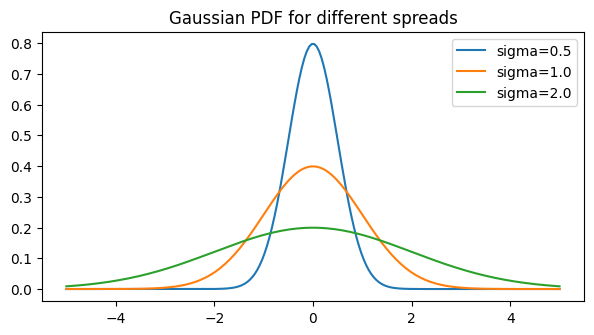

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# 1. Define the x-axis grid
x = np.linspace(-5, 5, 200)

# 2. Set up the plotting window
fig, ax = plt.subplots(figsize=(7, 3.5))

# 3. Plot the Gaussian curves for each standard deviation
for sigma in [0.5, 1.0, 2.0]:
    ax.plot(x, stats.norm(0, sigma).pdf(x), label=f'sigma={sigma}')

# 4. Format and display the graph
ax.set_title('Gaussian PDF for different spreads')
ax.legend()
plt.show()


Poisson(mu=2) Sample Mean: 2.0126 (True: 2.0)


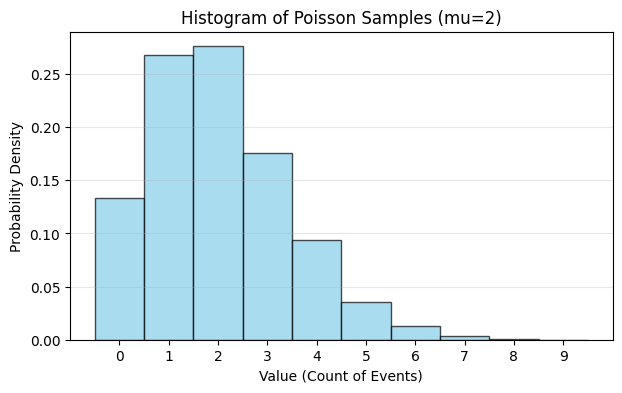

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# 1. Draw 10,000 samples from Poisson distribution (mu = 2)
mu_poisson = 2
poisson_samples = stats.poisson(mu=mu_poisson).rvs(size=10_000)

# 2. Print the sample mean
print(f"Poisson(mu=2) Sample Mean: {poisson_samples.mean():.4f} (True: 2.0)")

# 3. Plot the histogram of the samples
plt.figure(figsize=(7, 4))
bins = np.arange(0, poisson_samples.max() + 2) - 0.5
plt.hist(poisson_samples, bins=bins, density=True, color='skyblue', edgecolor='black', alpha=0.7)

plt.title('Histogram of Poisson Samples (mu=2)')
plt.xlabel('Value (Count of Events)')
plt.ylabel('Probability Density')
plt.xticks(range(0, poisson_samples.max() + 1))
plt.grid(axis='y', alpha=0.3)
plt.show()


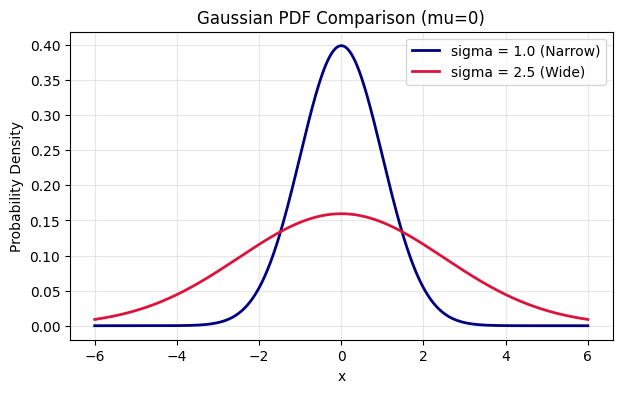

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# 1. Define x domain for plotting curves
x = np.linspace(-6, 6, 500)

# 2. Plot Gaussian PDFs with mu=0 and two different sigmas
plt.figure(figsize=(7, 4))
plt.plot(x, stats.norm(0, 1.0).pdf(x), label='sigma = 1.0 (Narrow)', color='navy', lw=2)
plt.plot(x, stats.norm(0, 2.5).pdf(x), label='sigma = 2.5 (Wide)', color='crimson', lw=2)

# 3. Chart formatting
plt.title('Gaussian PDF Comparison (mu=0)')
plt.xlabel('x')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [19]:
from scipy.stats import entropy

fair   = [0.5, 0.5]
biased = [0.9, 0.1]
certain= [1.0, 0.0]
print('Entropy fair coin   :', round(entropy(fair, base=2), 3), 'bits')
print('Entropy biased coin :', round(entropy(biased, base=2), 3), 'bits')
print('Entropy certain     :', round(entropy(certain, base=2), 3), 'bits')

Entropy fair coin   : 1.0 bits
Entropy biased coin : 0.469 bits
Entropy certain     : 0.0 bits


In [20]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.datasets import load_iris

iris = load_iris()
mi = mutual_info_classif(iris.data, iris.target, random_state=0)
for name, score in sorted(zip(iris.feature_names, mi), key=lambda t: -t[1]):
    print(f'{score:.3f}  {name}')
print('-> higher MI = the feature tells us more about the class')

0.990  petal length (cm)
0.975  petal width (cm)
0.474  sepal length (cm)
0.286  sepal width (cm)
-> higher MI = the feature tells us more about the class


In [21]:
import numpy as np
from scipy import stats

# 1. Entropy of a fair 4-sided and 6-sided die (use base=2)
entropy_4 = stats.entropy([1/4]*4, base=2)
entropy_6 = stats.entropy([1/6]*6, base=2)

print(f"Entropy of 4-sided die: {entropy_4:.3f} bits (True: 2.0)")
print(f"Entropy of 6-sided die: {entropy_6:.3f} bits (True: log2(6) ≈ 2.585)")


Entropy of 4-sided die: 2.000 bits (True: 2.0)
Entropy of 6-sided die: 2.585 bits (True: log2(6) ≈ 2.585)


In [22]:
import numpy as np
from scipy import stats

# 2. KL divergence D(P || Q)
P = np.array([0.7, 0.3])
Q = np.array([0.5, 0.5])

# stats.entropy computes KL divergence when a second distribution Q is provided
kl_div = stats.entropy(P, Q, base=2)

print(f"KL Divergence D(P || Q): {kl_div:.4f} bits")


KL Divergence D(P || Q): 0.1187 bits
